# Workshop on sensor processing using machine learning
Course: Intelligent Sensing and Sense Making

Website: https://www.iss.nus.edu.sg/executive-education/course/detail/intelligent-sensing-and-sense--making/artificial-intelligence

Contact: Tian Jing

Email: tianjing@nus.edu.sg

**Objective**: In this workshop, we will perform anomaly detection using autoencoder as reconstruction model. The machine health monitoring dataset is provided at https://github.com/ClockworkBunny/MHMS_DEEPLEARNING


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
print("PyTorch version is", torch.__version__)
# Use GPU if available else revert to CPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device being used:", device)


PyTorch version is 2.11.0+cu128
Device being used: cuda:0


In [2]:
# Grant access to google drive.
# Run this cell, then you’ll see a link, click on that link, allow access
# Copy the code that pops up, paste it in the box, hit Enter

from google.colab import drive
drive.mount('/content/gdrive')

# Change working directory to be current folder
# os.chdir('/content/gdrive/My Drive/Your Folder Name/Your sub Folder Name')
os.chdir('/content/gdrive/My Drive/ISSM/Day3')
!ls


Mounted at /content/gdrive
archive  data  ISSM_Day3_wk_anomaly_yourname.ipynb


In [3]:
# Load data
x_train_pd = pd.read_csv("data/machine_sensor_train.csv",header=None)
x_train = x_train_pd.values
x_test_pd = pd.read_csv("data/machine_sensor_test.csv",header=None)
x_test = x_test_pd.values

print('Train shape: ', x_train.shape, 'Test shape:', x_test.shape)

Train shape:  (600, 70) Test shape: (300, 70)


In [4]:
# Define the model
class myDataset(torch.utils.data.Dataset):
    def __init__(self, x_data):
        self.X = x_data
        self.num_samples = x_data.shape[0]

    def __getitem__(self, index):
        return self.X[index].astype('float32')

    def __len__(self):
        return self.num_samples

class myAEModel(nn.Module):
    def __init__(self, input_node, hidden_node):
        super(myAEModel, self).__init__()
        self.fc1 = nn.Sequential(nn.Linear(input_node, hidden_node), nn.ReLU())
        self.fc2 = nn.Sequential(nn.Linear(hidden_node, input_node)) # Note that the input signal has a range [-1,1], so we cannot use ReLU in the last layer

    def encode(self, x):
        z = self.fc1(x)
        return z

    def decode(self, x):
        z = self.fc2(x)
        return z

    def forward(self, x):
        z = self.encode(x)
        z = self.decode(z)
        return z

In [5]:
batch_size = 24
train_dataloader = torch.utils.data.DataLoader(myDataset(x_train), shuffle=True, batch_size=batch_size)

# # # Check dimension of a batch of training data
result = next(iter(train_dataloader))
print(result.shape)

input_node = x_train.shape[1]
hidden_node = 10
model = myAEModel(input_node, hidden_node)

model.to(device)
criterion = nn.MSELoss()
learning_rate = 1e-4
num_epoch = 20
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)

for epoch in range(num_epoch):
    running_loss = 0.0
    for i, data in enumerate(train_dataloader):
        data = data.to(device)

        output = model(data)
        loss_mse = criterion(data, output)

        optimizer.zero_grad()
        loss_mse.backward()
        optimizer.step()

        running_loss += loss_mse.cpu().item()

    print("Epoch: %d, loss: %.4f" % (epoch+1, loss_mse.cpu().item()))

torch.Size([24, 70])
Epoch: 1, loss: 0.5052
Epoch: 2, loss: 0.5640
Epoch: 3, loss: 0.5509
Epoch: 4, loss: 0.4556
Epoch: 5, loss: 0.4688
Epoch: 6, loss: 0.4953
Epoch: 7, loss: 0.4681
Epoch: 8, loss: 0.4091
Epoch: 9, loss: 0.4324
Epoch: 10, loss: 0.4381
Epoch: 11, loss: 0.3885
Epoch: 12, loss: 0.3687
Epoch: 13, loss: 0.3595
Epoch: 14, loss: 0.3517
Epoch: 15, loss: 0.3153
Epoch: 16, loss: 0.2956
Epoch: 17, loss: 0.2806
Epoch: 18, loss: 0.2584
Epoch: 19, loss: 0.2383
Epoch: 20, loss: 0.2338


In [6]:
# Select a test sample
sample_index = 0

# Step 1: Select the test sample (such as the 0-th sample)
test_data_orig = x_test[sample_index:sample_index+1,:]
test_data_orig = torch.from_numpy(test_data_orig.astype('float32'))

model.eval()
with torch.no_grad():

        test_data_orig = test_data_orig.to(device)
        output = model(test_data_orig)
        dist = F.pairwise_distance(test_data_orig, output)
        print('Dissimlarity: %.4f' % (dist.item()))

print('The reconstruction error is %.2f' % dist)


Dissimlarity: 4.2034
The reconstruction error is 4.20


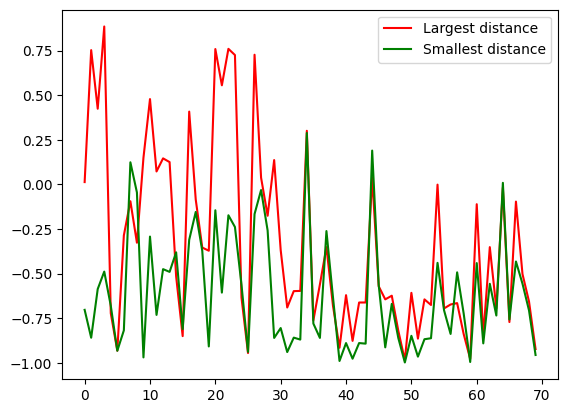

Minimum distance: 169-th sample, Error: 3.78
Maximum distance: 294-th sample, Error: 4.57


In [7]:
# Peform the test on x_test and determine the test data (row index) with the LARGEST reconstruction error based on the trained model
# Plot the data that is found by the model

dist_largest = 0
dist_smallest = 1e10
result_max = 0
result_min = 0

for sample_index in range (x_test.shape[0]):
    test_data_orig = x_test[sample_index:sample_index+1,:]

    # Step 1: Select the test sample (such as the 0-th sample)
    test_data_orig = x_test[sample_index:sample_index+1,:]
    test_data_orig = torch.from_numpy(test_data_orig.astype('float32'))

    model.eval()
    with torch.no_grad():

            test_data_orig = test_data_orig.to(device)
            output = model(test_data_orig)
            dist = F.pairwise_distance(test_data_orig, output)
            # print('Dissimlarity: %.4f' % (dist.item()))

    if (dist>dist_largest):
        dist_largest = dist
        result_max = sample_index
    if (dist<dist_smallest):
        dist_smallest = dist
        result_min = sample_index

plt.plot(x_test[result_max,:], 'r', label='Largest distance')
plt.plot(x_test[result_min,:], 'g', label='Smallest distance')
plt.legend()
plt.show()

print("Minimum distance: %d-th sample, Error: %.2f" % (result_min, dist_smallest))
print("Maximum distance: %d-th sample, Error: %.2f" % (result_max, dist_largest))

$\color{red}{\text{Discussions}}$

Q1: Recommend and describe a method to find a suitable threshold for the reconstruction error used in anomaly detection.

Q2: This workshop uses a generative autoencoder. If considering a contrastive autoencoder, suggest one method to construct the positive pair of samples and negative pair of samples for this task.

In [8]:
# Provide your answers to Q1
#
#
# Provide your answers to Q2
#
#


In [9]:
# AI Tool Declaration
# [Sample declaration copied from Canvas]
#
# The authors didn't use any AI tool.
#
# The authors used [AI tool name, e.g., GPT-5.1] to [describe specific uses: e.g., generate ideas, format paragraphs, improve expression,
# analyse effectiveness, create images and illustrations, produce drafts, refine, and/or finalise my assignment].
# The authors are responsible for the content and quality of the submitted work.
#
# [Provide your declaration here]
#
#
#


**After you finish the workshop, rename and submit your .ipynb file.**